In [5]:
import torch
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
# plt.style.use('tableau-colorblind10')


# Zones

In [ ]:
# 1. Define the configuration for each model type
# Format: { 'CleanName': 'File_Naming_Template' }
models_config = {
    # 0-4 done
    # "GRPO_Predict_RWR_mamba": "isaac_environment_Navigation_zones_shaper_None_GRPO_Predict_RWR_mamba_checkpoint_seed_{}.pt",

    # 0, 1 runnning
    # "GRPO_Predict_RWR_transformer": "isaac_environment_Navigation_zones_shaper_None_GRPO_Predict_RWR_transformer_checkpoint_seed_{}.pt",
    
    # 0 1, 2, 4 done, 3 running
    "GRPO_mamba": "isaac_environment_Navigation_zones_shaper_None_GRPO_mamba_checkpoint_seed_{}.pt",

    # 1, 2, 3, done,
    # "PPO_mamba": "isaac_environment_Navigation_zones_shaper_None_PPO_mamba_checkpoint_seed_{}.pt",
    
    # 0 done
    # "CyclER": "isaac_environment_Navigation_zones_automata_shaper_CyclER_PPO_actor_critic_MLP_checkpoint_seed_{}.pt"
}

cut_off = 1000

results_stats = {}
base_dir = "Paper_checkpoints/two_robots/"

# 2. Iterate through models and seeds
for model_name, path_template in models_config.items():
    rewards = []
    
    for i in range(4,5):
        path = base_dir + path_template.format(i)
        # Load directly into memory
        checkpoint = torch.load(path, map_location=torch.device('cpu'))
        rewards.append(checkpoint["average_reward"][:cut_off])
        
    # 3. Stack and calculate stats
    reward_stack = torch.stack(rewards)
    results_stats[model_name] = {
        "mean_reward_curve": reward_stack.mean(dim=0),
        "std_reward_curve": reward_stack.std(dim=0)
    }

    print(f"model_name: {model_name}, mean: {results_stats[model_name]['mean_reward_curve'][-1]}, std: {results_stats[model_name]['std_reward_curve'][-1]}")



# 4. Verify (Example with GRPO_mamba)
# m_stats = results_stats["GRPO_mamba"]
# print(f'Original length: {m_stats["mean_reward_curve"].shape}')
# print(f'Mean curve length: {m_stats["std_reward_curve"].shape}')

FileNotFoundError: [Errno 2] No such file or directory: 'Paper_checkpoints/two_robots/isaac_environment_Navigation_zones_shaper_None_GRPO_mamba_checkpoint_seed_3.pt'

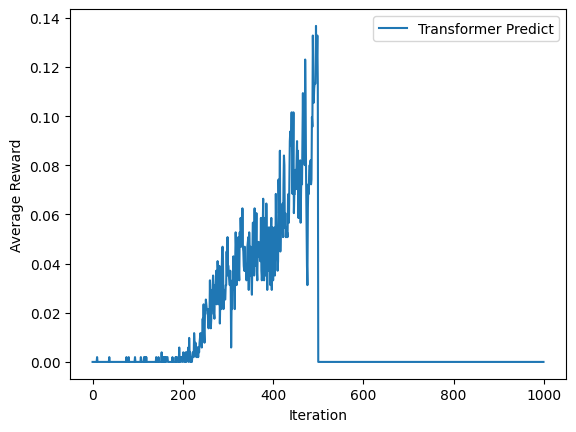

In [8]:
import matplotlib.pyplot as plt

# colors = [
#     "#0072B2",  # blue
#     "#E69F00",  # orange
#     "#009E73",  # teal (green alternative)
#     "#CC79A7"   # pink (instead of red)
# ]

# Mapping dictionary keys to nice legend labels
labels = {
    "GRPO_Predict_RWR_mamba": "Mamba Predict",
    "GRPO_Predict_RWR_transformer": "Transformer Predict",
    "GRPO_mamba": "GRPO",
    "PPO_mamba": "PPO",
    "CyclER": "CyclER"
}

fig, ax = plt.subplots()
x = torch.arange(0, cut_off)

for i, (key, stats) in enumerate(results_stats.items()):
    mean = stats["mean_reward_curve"][:cut_off]
    std = stats["std_reward_curve"][:cut_off]
    
    
    ax.plot(x, mean, label=labels.get(key, key))
    ax.fill_between(x, mean - std, mean + std, alpha=0.2)

ax.set_xlabel("Iteration")
ax.set_ylabel("Average Reward")
ax.legend()

plt.show()

# Two Robots

In [ ]:
# 1. Define the configuration for each model type
# Format: { 'CleanName': 'File_Naming_Template' }
models_config = {
    "GRPO_Predict_RWR_mamba": "isaac_environment_Navigation_buttons_two_robots_shaper_None_GRPO_Predict_RWR_mamba_checkpoint_seed_{}.pt",
    "GRPO_Predict_RWR_transformer": "isaac_environment_Navigation_buttons_two_robots_shaper_None_GRPO_Predict_RWR_transformer_checkpoint_seed_{}.pt",
    "GRPO_mamba": "isaac_environment_Navigation_buttons_two_robots_shaper_None_GRPO_mamba_checkpoint_seed_{}.pt",
    "PPO_mamba": "isaac_environment_Navigation_buttons_two_robots_shaper_None_PPO_mamba_checkpoint_seed_{}.pt",
    "CyclER": "isaac_environment_Navigation_buttons_two_robots_aut_shaper_CyclER_PPO_actor_critic_MLP_checkpoint_seed_{}.pt"
}

results_stats = {}
base_dir = "Paper_checkpoints/two_robots/"

# 2. Iterate through models and seeds
for model_name, path_template in models_config.items():
    rewards = []
    
    for i in range(5):
        # if i != 0:
            path = base_dir + path_template.format(i)
            # Load directly into memory
            checkpoint = torch.load(path, map_location=torch.device('cpu'))
            rewards.append(checkpoint["average_reward"][:500])
        
    # 3. Stack and calculate stats
    reward_stack = torch.stack(rewards)
    results_stats[model_name] = {
        "mean_reward_curve": reward_stack.mean(dim=0),
        "std_reward_curve": reward_stack.std(dim=0)
    }

    print(f"model_name: {model_name}, mean: {results_stats[model_name]['mean_reward_curve'][-1]}, std: {results_stats[model_name]['std_reward_curve'][-1]}")



# 4. Verify (Example with GRPO_mamba)
# m_stats = results_stats["GRPO_mamba"]
# print(f'Original length: {m_stats["mean_reward_curve"].shape}')
# print(f'Mean curve length: {m_stats["std_reward_curve"].shape}')

In [ ]:
import matplotlib.pyplot as plt

# colors = [
#     "#0072B2",  # blue
#     "#E69F00",  # orange
#     "#009E73",  # teal (green alternative)
#     "#CC79A7"   # pink (instead of red)
# ]

# Mapping dictionary keys to nice legend labels
labels = {
    "GRPO_Predict_RWR_mamba": "Mamba Predict",
    "GRPO_Predict_RWR_transformer": "Transformer Predict",
    "GRPO_mamba": "GRPO",
    "PPO_mamba": "PPO",
    "CyclER": "CyclER"
}

fig, ax = plt.subplots()
cut_off = 500
x = torch.arange(0, cut_off)

for i, (key, stats) in enumerate(results_stats.items()):
    mean = stats["mean_reward_curve"][:cut_off]
    std = stats["std_reward_curve"][:cut_off]
    
    
    ax.plot(x, mean, label=labels.get(key, key))
    ax.fill_between(x, mean - std, mean + std, alpha=0.2)

ax.set_xlabel("Iteration")
ax.set_ylabel("Average Reward")
ax.legend()

plt.show()

# Grid Environment

In [ ]:
# 1. Define the configuration for each model type
# Format: { 'CleanName': 'File_Naming_Template' }
models_config = {
    "GRPO_Predict_RWR_mamba": "grid_anbn_shaper_None_GRPO_Predict_RWR_mamba_MLP_hybrid_checkpoint_seed_{}.pt",
    "GRPO_Predict_RWR_transformer": "grid_anbn_shaper_None_GRPO_Predict_RWR_transformer_MLP_hybrid_checkpoint_seed_{}.pt",
    "GRPO_mamba": "grid_anbn_shaper_None_GRPO_mamba_checkpoint_seed_{}.pt",
    "PPO_mamba": "grid_anbn_shaper_None_PPO_mamba_checkpoint_seed_{}.pt"
}


results_stats = {}
base_dir = "Paper_checkpoints/grid_anbn/"
cut_off = 10000

# 2. Iterate through models and seeds
for model_name, path_template in models_config.items():
    rewards = []
    
    for i in range(5):
        path = base_dir + path_template.format(i)
        # Load directly into memory
        checkpoint = torch.load(path, map_location=torch.device('cpu'))
        rewards.append(checkpoint["average_reward"])
    
    # 3. Stack and calculate stats
    reward_stack = torch.stack(rewards)
    results_stats[model_name] = {
        "mean_reward_curve": reward_stack.mean(dim=0),
        "std_reward_curve": reward_stack.std(dim=0)
    }


    print(f"model_name: {model_name}, mean: {results_stats[model_name]['mean_reward_curve'][cut_off-1]}, std: {results_stats[model_name]['std_reward_curve'][cut_off-1]}")

# 4. Verify (Example with GRPO_mamba)
m_stats = results_stats["GRPO_mamba"]
print(f'Original length: {m_stats["mean_reward_curve"].shape}')
print(f'Mean curve length: {m_stats["std_reward_curve"].shape}')

In [ ]:
import matplotlib.pyplot as plt

# colors = [
#     "#0072B2",  # blue
#     "#E69F00",  # orange
#     "#009E73",  # teal (green alternative)
#     "#CC79A7"   # pink (instead of red)
# ]

# Mapping dictionary keys to nice legend labels
labels = {
    "GRPO_Predict_RWR_mamba": "Mamba Predict",
    "GRPO_Predict_RWR_transformer": "Transformer Predict",
    "GRPO_mamba": "GRPO",
    "PPO_mamba": "PPO"
}

fig, ax = plt.subplots()
x = torch.arange(0, cut_off)

for i, (key, stats) in enumerate(results_stats.items()):
    mean = stats["mean_reward_curve"][:cut_off]
    std = stats["std_reward_curve"][:cut_off]
    
    
    ax.plot(x, mean, label=labels.get(key, key))
    ax.fill_between(x, mean - std, mean + std, alpha=0.2)



ax.set_xlabel("Iteration")
ax.set_ylabel("Average Reward")
ax.legend()

plt.show()

In [ ]:
checkpoint_path = f"checkpoints/isaac_environment_Navigation_zones_RWR_predict_mamba_MLP_hybrid_270_secs_checkpoint_Apr_9.pt"ArithmeticError
checkpoint_path = torch.load(checkpoint_path, map_location=torch.device('cpu'))

fig, ax = plt.subplots()

cut_off = 2400

ax.plot(checkpoint_path["average_reward"][:cut_off], label="CyclER")

# ax.plot(new["average_reward"][:cut_off], label="GRPO_Predict")

ax.set_xlabel("Iteration")
ax.set_ylabel("Average Reward")

ax.legend()

plt.show()


In [ ]:
# # import torch
# # import os

# # # 1. Recreate the path (make sure these variables match what you used to save)
# # # checkpoint_path = f"checkpoints/isaac_RWR_mamba_trunc_200_checkpoint.pt"

# # #checkpoint_path = f"checkpoints/buttons_mamba_scratch_checkpoint.pt"

# # # checkpoint_path = f"checkpoints/isaac_environment_Navigation_zones_4_away_RWR_mamba_180_secs_checkpoint.pt"
# # # checkpoint_path = f"checkpoints/isaac_environment_Navigation_zones_4_away_RWR_mamba_180_secs_checkpoint.pt"
# # # checkpoint_path = f"checkpoints/isaac_environment_Navigation_buttons_4_away_RWR_mamba_180_secs_checkpoint.pt"
# # # checkpoint_path = f"checkpoints/isaac_environment_Navigation_buttons_4_away_RWR_predict_mamba_90_secs_checkpoint.pt"

# # # grid world

# # # checkpoint_path_mamba_MLP = f"checkpoints/grid_buttons_shaper_None_RWR_predict_mamba_MLP_hybrid_checkpoint.pt"
# # # checkpoint_path_MLP_cycler = f"checkpoints/grid_buttons_shaper_CyclER_PPO_actor_critic_MLP_checkpoint.pt"

# # # checkpoint_path_mamba_MLP = f"checkpoints/grid_zones_shaper_None_RWR_predict_mamba_MLP_hybrid_checkpoint.pt"
# # # checkpoint_path_MLP_cycler = f"checkpoints/grid_zones_shaper_CyclER_PPO_actor_critic_MLP_checkpoint.pt"

# # # start_epoch = checkpoint_path_mamba_MLP["epoch"]
# # # average_reward_mamba_MLP = checkpoint_path_mamba_MLP["average_reward"]
# # # max_reward = checkpoint_path_mamba_MLP["max_reward"]


# # # Isaac Lab

# # # buttons
# # # checkpoint_path_mamba = f"checkpoints/isaac_environment_Navigation_buttons_4_away_RWR_predict_mamba_90_secs_checkpoint.pt"

# # # zones
# # # checkpoint_path_mamba = f"checkpoints/isaac_environment_Navigation_zones_4_away_RWR_mamba_180_secs_checkpoint.pt"
# # # checkpoint_path_mamba = f"checkpoints/isaac_environment_Navigation_zones_3_away_RWR_predict_mamba_90_secs_checkpoint.pt"

# # # checkpoint_path_mamba = torch.load(checkpoint_path_mamba, map_location=torch.device('cpu'))
# # # checkpoint_path_MLP_cycler = torch.load(checkpoint_path_MLP_cycler, map_location=torch.device('cpu'))



# # # start_epoch = checkpoint_path_mamba["epoch"]
# # # average_reward_mamba_MLP = checkpoint_path_mamba["average_reward"]
# # # max_reward = checkpoint_path_mamba["max_reward"]


# # # average_reward_MLP_cycler = checkpoint_path_MLP_cycler["average_reward"]


# # ## two robots

# # # checkpoint_path = f"checkpoints/isaac_environment_Navigation_buttons_two_robots_3_away_RWR_predict_mamba_90_secs_checkpoint_2.pt"

# # # checkpoint_path_shape = f"checkpoints/isaac_environment_Navigation_buttons_automata_PPO_actor_critic_MLP_90_secs_checkpoint_2.pt"
# # # checkpoint_path_true = f"checkpoints/isaac_environment_Navigation_buttons_automata_PPO_actor_critic_MLP_90_secs_checkpoint_2.pt"



# # # For buttons
# checkpoint_path_Cycler_path = "checkpoints/grid_buttons_shaper_CyclER_PPO_actor_critic_MLP_checkpoint_apr_1.pt"
# checkpoint_path_mamba_hybrid_predictor_path = "checkpoints/grid_buttons_shaper_None_RWR_predict_mamba_MLP_hybrid_checkpoint_apr_1.pt"
# checkpoint_path_GRPO_path = "checkpoints/grid_buttons_shaper_None_GRPO_mamba_checkpoint_apr_1.pt"
# checkpoint_path_transformer_hybrid_predictor_path = "checkpoints/grid_buttons_shaper_None_RWR_predict_transformer_MLP_hybrid_checkpoint_apr_1.pt"
# checkpoint_path_PPO_path = "checkpoints/grid_buttons_shaper_None_PPO_mamba_checkpoint_apr_1.pt"

# For zones
checkpoint_path_Cycler_path = "checkpoints/grid_zones_shaper_CyclER_PPO_actor_critic_MLP_checkpoint_apr_1.pt"
checkpoint_path_mamba_hybrid_predictor_path = "checkpoints/grid_zones_shaper_None_RWR_predict_mamba_MLP_hybrid_checkpoint_apr_1.pt"
checkpoint_path_GRPO_path = "checkpoints/grid_zones_shaper_None_GRPO_mamba_checkpoint_apr_1.pt"
checkpoint_path_transformer_hybrid_predictor_path = "checkpoints/grid_zones_shaper_None_RWR_predict_transformer_MLP_hybrid_checkpoint_apr_1.pt"
checkpoint_path_PPO_path = "checkpoints/grid_zones_shaper_None_PPO_mamba_checkpoint_apr_1.pt"
checkpoint_path_GRPO_predict_path =  "checkpoints/grid_zones_shaper_None_GRPO_Predict_mamba_MLP_hybrid_checkpoint_apr_1.pt"

checkpoint_path_Cycler = torch.load(checkpoint_path_Cycler_path, map_location=torch.device('cpu'))
checkpoint_path_mamba_hybrid_predictor = torch.load(checkpoint_path_mamba_hybrid_predictor_path, map_location=torch.device('cpu'))
checkpoint_path_transformer_hybrid_predictor = torch.load(checkpoint_path_transformer_hybrid_predictor_path, map_location=torch.device('cpu'))
checkpoint_path_GRPO = torch.load(checkpoint_path_GRPO_path, map_location=torch.device('cpu'))
checkpoint_path_PPO = torch.load(checkpoint_path_PPO_path, map_location=torch.device('cpu'))
checkpoint_path_mamba_GRPO = torch.load(checkpoint_path_GRPO_predict_path, map_location=torch.device('cpu'))



# # # start_epoch_true = checkpoint_path["epoch"]
# # # average_reward_true = checkpoint_path["average_reward"]
# # # average_reward_shape = checkpoint_path["average_reward_shape"]
# # # max_reward_true = checkpoint_path["max_reward"]





In [ ]:
fig, ax = plt.subplots()

cut_off = 2400

ax.plot(checkpoint_path_Cycler["average_reward"][:cut_off], label="CyclER")
ax.plot(checkpoint_path_mamba_hybrid_predictor["average_reward"][:cut_off], label="Mamba Predictor")
ax.plot(checkpoint_path_transformer_hybrid_predictor["average_reward"][:cut_off], label="Transformer Predictor")
ax.plot(checkpoint_path_mamba_GRPO["average_reward"][:cut_off], label="Mamba Predictor GRPO Actor")
ax.plot(checkpoint_path_GRPO["average_reward"][:cut_off], label="GRPO")
ax.plot(checkpoint_path_PPO["average_reward"][:cut_off], label="PPO")

# ax.plot(new["average_reward"][:cut_off], label="GRPO_Predict")

ax.set_xlabel("Iteration")
ax.set_ylabel("Average Reward")

ax.legend()

plt.show()

In [ ]:
## For continuous actions

In [ ]:

GRPO_predict = "checkpoints/isaac_environment_cont_Navigation_buttons_GRPO_Predict_mamba_MLP_hybrid_180_secs_checkpoint_Apr_5.pt"
RWR_predict = "checkpoints/isaac_environment_cont_Navigation_buttons_RWR_Predict_cont_mamba_MLP_hybrid_180_secs_checkpoint_Apr_5.pt"

GRPO_predict = torch.load(GRPO_predict, map_location=torch.device('cpu'))
RWR_predict = torch.load(RWR_predict, map_location=torch.device('cpu'))




In [ ]:
fig, ax = plt.subplots()

cut_off=750

ax.plot(GRPO_predict["average_reward"][:cut_off], label="GRPO Predict")
ax.plot(RWR_predict["average_reward"][:cut_off], label="RWR Predictor")

ax.set_xlabel("Iteration")
ax.set_ylabel("Average Reward")

ax.legend()

plt.show()

In [ ]:

GRPO_predict = "checkpoints/grid_anbn_shaper_None_GRPO_Predict_RWR_mamba_MLP_hybrid_checkpoint_seed_0_410.pt"

GRPO_predict_RWR = "checkpoints/grid_anbn_shaper_None_GRPO_Predict_RWR_mamba_MLP_hybrid_checkpoint_seed_0_410.pt"

GRPO_predict = torch.load(GRPO_predict, map_location=torch.device('cpu'))
predict = torch.load(GRPO_predict_RWR, map_location=torch.device('cpu'))


In [ ]:
GRPO_Predict = GRPO_predict_RWR

In [ ]:
fig, ax = plt.subplots()

cut_off=4500

ax.plot(GRPO_predict["average_reward"][:cut_off], label="GRPO Predict RWR")
# ax.plot(predict["average_reward"][:cut_off], label="GRPO RWR Predictor")

ax.set_xlabel("Iteration")
ax.set_ylabel("Average Reward")

ax.legend()

plt.show()

In [ ]:
cut_off

fig, ax = plt.subplots()

ax.plot(GRPO_predict["prediction_error"][:cut_off], label="GRPO")
ax.plot(GRPO_predict_RWR["prediction_error"][:cut_off], label="GRPO standarad Adv.")

ax.set_xlabel("Iteration")
ax.set_ylabel("Mean Square Error (MSE)")

ax.legend()

plt.show()


prediction_error_mamba_smoothed = torch.zeros_like(checkpoint_path_mamba_hybrid_predictor["prediction_error"])
prediction_error_transformer_smoothed = torch.zeros_like(checkpoint_path_transformer_hybrid_predictor["prediction_error"])

l = 100

for i in range(prediction_error_mamba_smoothed.shape[0]-l):
    prediction_error_mamba_smoothed[i] = checkpoint_path_mamba_hybrid_predictor["prediction_error"][i:i+l].mean()
    prediction_error_transformer_smoothed[i] = checkpoint_path_transformer_hybrid_predictor["prediction_error"][i:i+l].mean()


fig, ax = plt.subplots()

ax.plot(prediction_error_mamba_smoothed[:cut_off], label="Mamba Predictor")
ax.plot(prediction_error_transformer_smoothed[:cut_off], label="Transformer Predictor")

ax.set_xlabel("Iteration")
ax.set_ylabel("Mean Square Error (MSE)")

ax.legend()

plt.show()


In [ ]:
fig, ax = plt.subplots()

ax.plot(average_reward_shape[:300])
# ax.plot(average_reward_MLP_cycler[:4000], label="CYCler")


ax.set_xlabel("Iteration")
ax.set_ylabel("Average Reward")

# ax.legend()

plt.show()


In [ ]:
fig, ax = plt.subplots()

ax.plot(average_reward_mamba_MLP[:400], label="Mamba")
# ax.plot(average_reward_MLP_cycler[:4000], label="CYCler")


ax.set_xlabel("Iteration")
ax.set_ylabel("Average Reward")

ax.legend()

plt.show()




## Safety Gymnasium

In [ ]:



# path = f"average_reward_safe_gym_SafetyPointGoal1-v0_1000_epochs_lr_1e-06_beta_1.pt"
# path = f"data/average_reward_safe_gym_SafetyPointGoal1-v0_1000_epochs_lr_0.001_beta_10.pt"

# path = "data/architecture_RoPE_reward_size_10_temp_10_beta_100_epochs_10000_num_envs_180.pt"

# path = "data/Average_Reward_mamba_feature_learning__model_afer_4999_epochs_RWR.pt"

# path = "data/Average_Reward_buttons_epochs_RWR.pt"
path = "data/Average_Reward_buttons_4_epochs_RWR.pt"


data_mamba = torch.load(path)

# path = "data/Average_Reward_trans_feature_learning__model_afer_4999_epochs_RWR.pt"

# data_trans = torch.load(path)

path = "data/Cycler_Average_Reward_buttons_2.pt"


data_MLP = torch.load(path)




In [ ]:
fig, ax = plt.subplots()

ax.plot(data_mamba["average_reward"][:1400], label="Mamba")
ax.plot(data_MLP["average_reward"][:1400], label="Cycler")

ax.set_xlabel("Iteration")
ax.set_ylabel("Average Reward")

ax.legend()

fig, ax = plt.subplots()

# ax.plot(data_MLP["average_reward"][:130], label="Cycler")
ax.set_xlabel("Iteration")
ax.set_ylabel("Average Reward")

ax.legend()

plt.show()

fig, ax = plt.subplots()

ax.plot(data_mamba["safe"][:800])
ax.set_xlabel("Iteration")
ax.set_ylabel("Satisfies")

plt.show()


fig, ax = plt.subplots()

ax.plot(data_mamba["max_reward"][:800])
ax.set_xlabel("Iteration")
ax.set_ylabel("Max Reward")

plt.show()




## Grid World buttons

In [ ]:

path = "data/Cycler_Average_Reward_grid_buttons_max_Steps_100.pt"

data_cycler = torch.load(path)

path = "data/RWR_Average_Reward_grid_buttons_max_Steps_100.pt"

data_mamba = torch.load(path)

fig, ax = plt.subplots()

ax.plot(data_mamba["average_reward"], label="RWR")
ax.plot(data_cycler["average_reward"], label="Cycler")



# ax.plot(stats_Transformer_Nope["average_reward"], label="Trans. NoPE")
# ax.plot(stats_Transformer_RoPE["average_reward"], label="Trans. RoPE")
# ax.plot(stats_Mamba["average_reward"], label="Mamba")

ax.set_xlabel("Iteration")
ax.set_ylabel("Average Reward")

ax.legend()

fig, ax = plt.subplots()

ax.plot(data_cycler["reward_shape"].cpu())
ax.set_xlabel("Iteration")
ax.set_ylabel("Shaped Reward")

plt.show()





## Zones

In [ ]:

path = "data/Cycler_Average_Reward_zones_max_Steps_200.pt"

data_cycler = torch.load(path)

path = "data/RWR_Average_Reward_zones_max_Steps_200.pt"

data_mamba = torch.load(path)

fig, ax = plt.subplots()

ax.plot(data_mamba["average_reward"], label="RWR")
ax.plot(data_cycler["average_reward"], label="Cycler")
ax.set_xlabel("Iteration")
ax.set_ylabel("Average Reward")


# ax.plot(stats_Transformer_Nope["average_reward"], label="Trans. NoPE")
# ax.plot(stats_Transformer_RoPE["average_reward"], label="Trans. RoPE")
# ax.plot(stats_Mamba["average_reward"], label="Mamba")



ax.legend()

fig, ax = plt.subplots()

ax.plot(data_cycler["reward_shape"].cpu())
ax.set_xlabel("Iteration")
ax.set_ylabel("Shaped Reward")

plt.show()

